<a href="https://colab.research.google.com/github/AROO-6/Thiranex_task/blob/main/Thiranex(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)

# Load dataset
data = load_iris()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (120, 4), Test: (30, 4)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "preds": preds, "acc": acc}
    print(f"{name}: {acc:.4f}")

Logistic Regression: 1.0000
Decision Tree: 1.0000
Random Forest: 1.0000


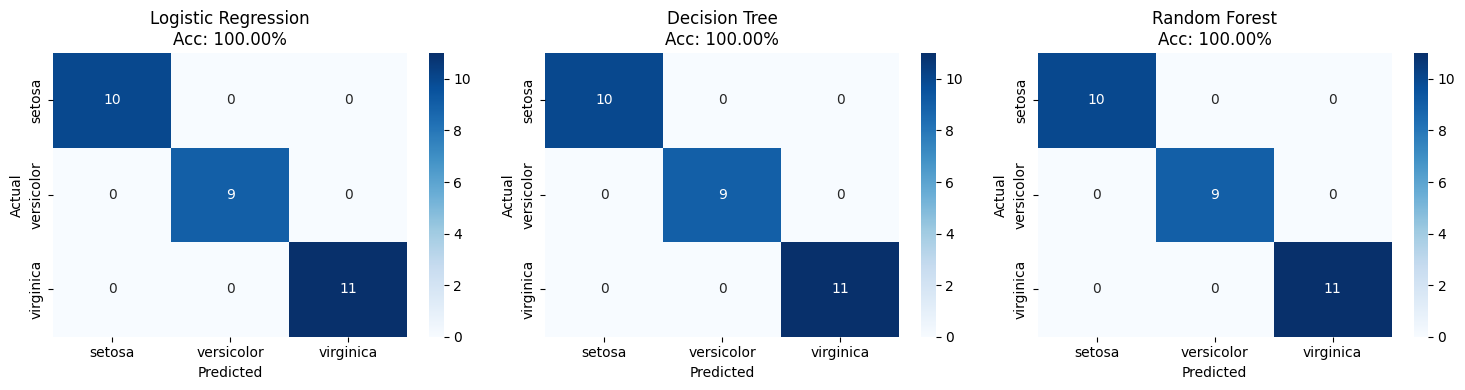

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{name}\nAcc: {r['acc']:.2%}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

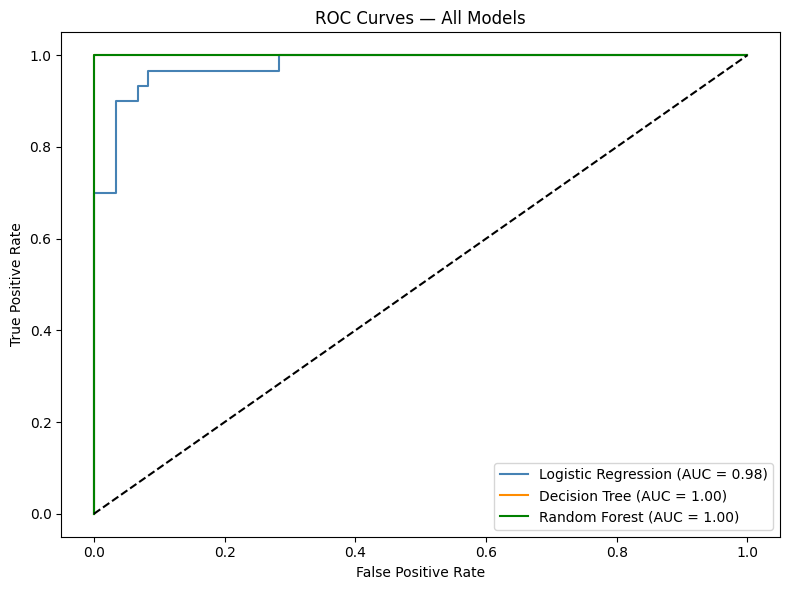

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

y_bin = label_binarize(y, classes=[0, 1, 2])
X_tr, X_te, y_tr, y_te = train_test_split(X, y_bin, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 6))
colors = ["steelblue", "darkorange", "green"]

for (name, _), color in zip(models.items(), colors):
    clf = OneVsRestClassifier(list(models.values())[list(models.keys()).index(name)])
    clf.fit(X_tr, y_tr)
    y_score = clf.predict_proba(X_te)
    fpr, tpr, _ = roc_curve(y_te.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.tight_layout()
plt.show()

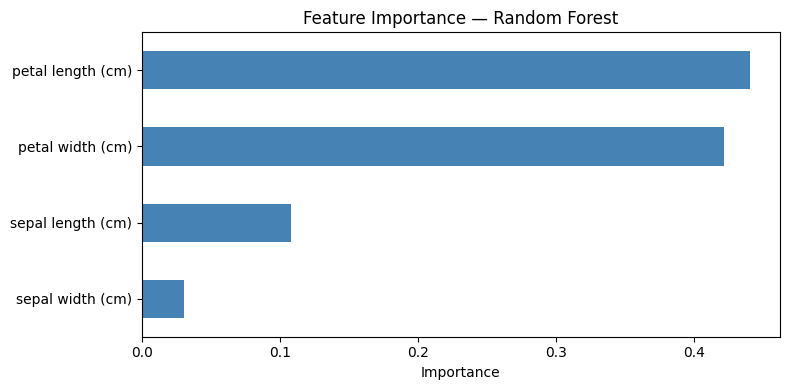

In [ ]:
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values()

importances.plot(kind="barh", figsize=(8, 4), color="steelblue")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
for name, r in results.items():
    print(f"\n{'='*40}\n{name}\n{'='*40}")
    print(classification_report(y_test, r["preds"], target_names=class_names))


Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00 